<a href="https://colab.research.google.com/github/Ashritha0848/NLP/blob/main/2403A52229%2CBatch_9%2CAssignment_10_2%2CNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.9 MB/s eta 0:00:00


In [2]:
# ================================
# Loading Pre-trained Embeddings
# ================================
from gensim.models import KeyedVectors
import gensim.downloader as api

# ================================
# Handling Matrices & Numerical Operations
# ================================
import numpy as np

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt

# ================================
# t-SNE for Dimensionality Reduction
# ================================
from sklearn.manifold import TSNE

In [3]:
# Load pre-trained Word2Vec model (may take time on first download)
model_word2vec = api.load("word2vec-google-news-300")
model_glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[==================================================] 100.0% 128.1/128.1MB downloaded


In [5]:
word_list = [

    #  Animals (10)
    "lion", "tiger", "elephant", "giraffe", "zebra",
    "dog", "cat", "horse", "monkey", "bear",

    #  Countries (10)
    "india", "china", "france", "germany", "brazil",
    "canada", "australia", "japan", "italy", "mexico",

    # Professions (10)
    "doctor", "engineer", "teacher", "lawyer", "nurse",
    "scientist", "pilot", "chef", "artist", "farmer",

    #  Technology (10)
    "computer", "internet", "software", "hardware", "robot",
    "keyboard", "laptop", "smartphone", "database", "network",

    #  Emotions (10)
    "happy", "sad", "angry", "joy", "fear",
    "love", "hate", "excited", "anxious", "calm"
]

In [6]:
vectors = [model_word2vec[word] for word in word_list if word in model_word2vec]

# Convert to NumPy array
vectors_word2vec = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_word2vec[0])

Total selected words: 50
Vector shape: (50, 300)
[ 2.12890625e-01 -4.57763672e-03 -2.36328125e-01  4.56542969e-02
  1.34765625e-01 -1.36718750e-01 -1.40991211e-02 -1.22558594e-01
  3.80859375e-02 -2.12097168e-03 -1.57226562e-01  5.92041016e-03
 -1.87500000e-01 -9.86328125e-02 -4.64843750e-01 -3.27148438e-02
 -2.51953125e-01  1.50146484e-02 -2.37304688e-01 -1.05468750e-01
 -6.44531250e-02 -2.19726562e-01  3.80859375e-01 -6.78710938e-02
  1.67968750e-01  1.31835938e-01 -3.65234375e-01  9.08203125e-02
  1.94335938e-01  2.12097168e-03 -1.25000000e-01 -1.01074219e-01
 -2.05078125e-02  1.79687500e-01 -6.29882812e-02 -1.00097656e-01
 -3.82812500e-01  2.73437500e-01  1.89453125e-01  2.61718750e-01
  2.14843750e-01 -2.03125000e-01  1.56250000e-01  2.15820312e-01
  1.06933594e-01 -3.12500000e-02  2.41210938e-01 -1.20239258e-02
  3.24218750e-01 -1.86523438e-01 -1.11328125e-01  3.71093750e-02
  5.17578125e-02 -1.67968750e-01 -5.44433594e-02 -2.88391113e-03
 -2.96630859e-02 -1.20117188e-01  3.67187

In [7]:
vectors = [model_glove[word] for word in word_list if word in model_glove]

# Convert to NumPy array
vectors_glove = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_glove.shape)
print(vectors_glove[0])

Total selected words: 50
Vector shape: (50, 100)
[ 1.9713e-01  4.3847e-01  3.3630e-01 -3.0903e-01  5.1632e-01  3.6911e-01
 -7.7066e-01 -2.6882e-01 -8.4738e-01 -1.1849e+00 -5.2657e-01  4.2716e-01
  3.1811e-01  1.2596e-01 -4.2878e-01  5.7082e-01  9.8343e-02 -2.8419e-01
 -1.0815e-01  5.2569e-01  2.4329e-01 -5.7011e-01 -5.9246e-01 -7.9165e-02
  5.6696e-01  9.5197e-01 -5.1655e-01  2.4623e-01 -3.4456e-02 -4.8879e-01
  4.7730e-01 -3.8298e-01  3.4114e-01  1.2379e-01  7.2175e-01  3.5767e-01
 -2.1807e-01  8.5154e-01  3.4198e-01  9.1585e-04  7.1398e-01  3.5306e-01
 -4.2911e-01  7.7116e-02  5.5031e-01  8.3248e-01 -5.6847e-01 -1.1818e-01
 -1.3059e-01 -2.1793e-01 -8.0428e-01  3.2947e-01  2.2659e-01  9.9647e-01
 -8.9859e-01 -1.7248e+00 -5.5854e-01  1.8703e-01  1.5013e-01 -5.4897e-01
  7.4180e-01  3.2988e-01 -6.1525e-01  5.9511e-01  2.1116e-01  6.6720e-01
 -6.9245e-02 -4.0357e-02  6.3197e-02  7.3402e-01 -1.4801e-03 -7.5396e-01
 -1.4958e-01  5.1955e-01 -3.5270e-01 -7.3562e-01 -7.8484e-01  1.7187e-01
 -

In [8]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_word2vec)

# Store results
print("Original Shape:", vectors_word2vec.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of word2vec
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_word2vec[:5])

Original Shape: (50, 300)
Reduced Shape: (50, 2)

First 5 t-SNE Coordinates:
[[121.511086 -33.019833]
 [105.90179  -67.149475]
 [118.45495  -63.55765 ]
 [132.65172  -53.669285]
 [139.50316  -64.8181  ]]

First 5 t-SNE Coordinates:
[[ 0.21289062 -0.00457764 -0.23632812 ... -0.13867188 -0.19921875
   0.17675781]
 [-0.06835938  0.18261719 -0.17773438 ...  0.19042969 -0.10205078
   0.17285156]
 [ 0.02001953  0.31445312 -0.27734375 ...  0.33007812 -0.37109375
   0.20605469]
 [-0.0559082   0.33007812 -0.39648438 ...  0.15625    -0.28125
   0.09326172]
 [-0.08544922 -0.10253906 -0.48632812 ...  0.02075195  0.08496094
   0.00061035]]


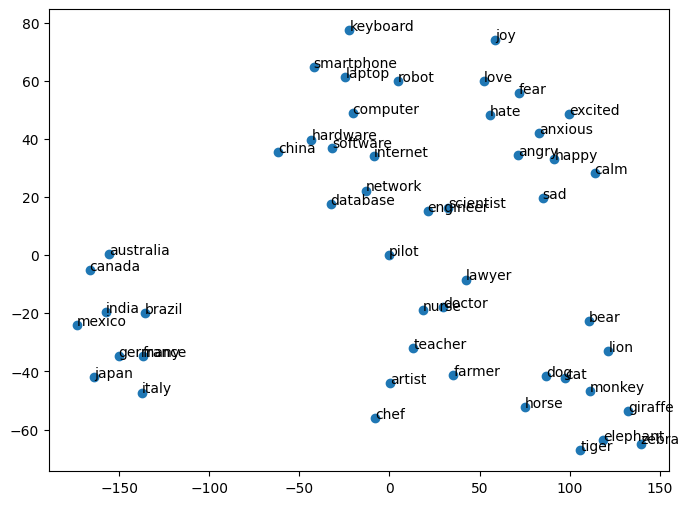

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()

In [10]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_glove)

# Store results
print("Original Shape:", vectors_glove.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of glove
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_glove[:5])

Original Shape: (50, 100)
Reduced Shape: (50, 2)

First 5 t-SNE Coordinates:
[[46.587322 18.27528 ]
 [58.319305 11.439033]
 [48.128735 29.90788 ]
 [52.128574 43.483967]
 [55.28429  52.441013]]

First 5 t-SNE Coordinates:
[[ 1.9713e-01  4.3847e-01  3.3630e-01 -3.0903e-01  5.1632e-01  3.6911e-01
  -7.7066e-01 -2.6882e-01 -8.4738e-01 -1.1849e+00 -5.2657e-01  4.2716e-01
   3.1811e-01  1.2596e-01 -4.2878e-01  5.7082e-01  9.8343e-02 -2.8419e-01
  -1.0815e-01  5.2569e-01  2.4329e-01 -5.7011e-01 -5.9246e-01 -7.9165e-02
   5.6696e-01  9.5197e-01 -5.1655e-01  2.4623e-01 -3.4456e-02 -4.8879e-01
   4.7730e-01 -3.8298e-01  3.4114e-01  1.2379e-01  7.2175e-01  3.5767e-01
  -2.1807e-01  8.5154e-01  3.4198e-01  9.1585e-04  7.1398e-01  3.5306e-01
  -4.2911e-01  7.7116e-02  5.5031e-01  8.3248e-01 -5.6847e-01 -1.1818e-01
  -1.3059e-01 -2.1793e-01 -8.0428e-01  3.2947e-01  2.2659e-01  9.9647e-01
  -8.9859e-01 -1.7248e+00 -5.5854e-01  1.8703e-01  1.5013e-01 -5.4897e-01
   7.4180e-01  3.2988e-01 -6.1525e-01  

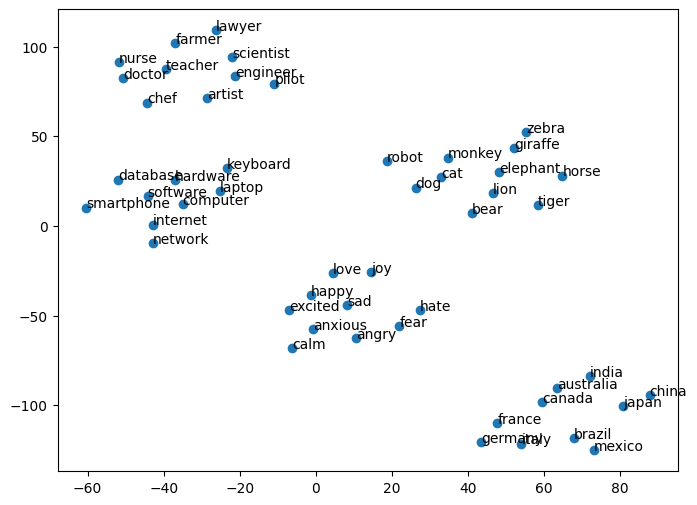

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()